**Project on IWS water characteristics**

Team members

Lokesh Patchala

Manideep Reddy, Kasi reddy

chaitanya kumar kantem

Gurrala Shashaank reddy

Vasavi Yasam

Maheshwari Jagathpally

In [ ]:
! pip install rfpimp

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for rfpimp: filename=rfpimp-1.3.7-py3-none-any.whl size=10668 sha256=1043d8e93a327ca38c96ad619e168427fff75f9cb256fea3883d56d1c339aa98
  Stored in directory: /root/.cache/pip/wheels/8a/42/e5/d2e9d77df351103d7d16dbc82ce6090cb2f71cee74b7380b7b
Successfully built rfpimp


In [ ]:

import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import rfpimp
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
warnings.filterwarnings('ignore')


In [ ]:
water = pd.read_csv('WaterData.csv')

In [ ]:
water = water.replace(r'^\s*$', np.nan, regex=True)

In [ ]:
water.head()

,Date,Total Solids,SS,BOD5,NH3,Org-N,P-TOT,SO4,TKN,PRCP_NOOA
0,2001-01-01,984.0,170.0,173,15.93,14.0,4.58,72,29.97,0.0
1,2001-01-02,924.0,122.0,174,15.52,14.4,4.52,72,29.96,0.0
2,2001-01-03,1135.0,300.0,303,14.19,21.9,6.06,NaN,36.11,0.0
3,2001-01-04,1013.0,192.0,228,15.43,19.4,5.33,NaN,34.83,0.0
4,2001-01-05,1088.0,226.0,210,14.77,19.3,5.41,NaN,34.06,0.0


In [ ]:
water.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          6574 non-null   object 
 1   Total Solids  6567 non-null   float64
 2   SS            6564 non-null   float64
 3   BOD5          6386 non-null   object 
 4   NH3           6565 non-null   float64
 5   Org-N         6565 non-null   float64
 6   P-TOT         6566 non-null   object 
 7   SO4           939 non-null    object 
 8   TKN           6567 non-null   float64
 9   PRCP_NOOA     6574 non-null   float64
dtypes: float64(6), object(4)
memory usage: 513.7+ KB


In [ ]:
water.describe()

,Total Solids,SS,NH3,Org-N,TKN,PRCP_NOOA
count,6567.000000,6564.000000,6565.000000,6565.000000,6567.000000,6574.000000
mean,956.687833,183.891225,15.026084,11.215575,26.283914,0.106879
std,220.591086,133.788441,5.142506,4.883816,8.290948,0.320376
min,306.000000,12.000000,0.760000,0.000000,0.400000,0.000000
25%,846.000000,118.000000,11.640000,8.800000,21.900000,0.000000
50%,936.000000,167.000000,15.480000,11.100000,27.400000,0.000000
75%,1041.000000,216.000000,18.700000,13.240000,31.600000,0.040000
max,3759.000000,3170.000000,33.060000,110.700000,142.300000,6.860000


In [ ]:
for i in range(water.shape[0]):
    try:
        water['SO4'].iloc[i] = float(water['SO4'].iloc[i])
    except:
        water['SO4'].iloc[i] = np.nan

In [ ]:
for i in range(water.shape[0]):
    try:
        water['BOD5'].iloc[i] = float(water['BOD5'].iloc[i])
    except:
        water['BOD5'].iloc[i] = np.nan

In [ ]:
for i in range(water.shape[0]):
    try:
        water['P-TOT'].iloc[i] = float(water['P-TOT'].iloc[i])
    except:
        water['P-TOT'].iloc[i] = np.nan

### SO4 has many null values, imputing values using farward fill


In [ ]:
water['SO4'].interpolate("ffill", inplace = True)

In [ ]:
water.head()

,Date,Total Solids,SS,BOD5,NH3,Org-N,P-TOT,SO4,TKN,PRCP_NOOA
0,2001-01-01,984.0,170.0,173.0,15.93,14.0,4.58,72.0,29.97,0.0
1,2001-01-02,924.0,122.0,174.0,15.52,14.4,4.52,72.0,29.96,0.0
2,2001-01-03,1135.0,300.0,303.0,14.19,21.9,6.06,72.0,36.11,0.0
3,2001-01-04,1013.0,192.0,228.0,15.43,19.4,5.33,72.0,34.83,0.0
4,2001-01-05,1088.0,226.0,210.0,14.77,19.3,5.41,72.0,34.06,0.0


In [ ]:

water['BOD5'].interpolate("ffill", inplace = True)
water['P-TOT'].interpolate("ffill", inplace = True)

In [ ]:
water.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          6574 non-null   object 
 1   Total Solids  6567 non-null   float64
 2   SS            6564 non-null   float64
 3   BOD5          6574 non-null   float64
 4   NH3           6565 non-null   float64
 5   Org-N         6565 non-null   float64
 6   P-TOT         6574 non-null   float64
 7   SO4           6574 non-null   float64
 8   TKN           6567 non-null   float64
 9   PRCP_NOOA     6574 non-null   float64
dtypes: float64(9), object(1)
memory usage: 513.7+ KB


### check for null values

In [ ]:
water.isnull().sum()

Date             0
Total Solids     7
SS              10
BOD5             0
NH3              9
Org-N            9
P-TOT            0
SO4              0
TKN              7
PRCP_NOOA        0
dtype: int64

### check the columns. Total there are 9 columns. we will build 9-different models

In [ ]:
water.columns

Index(['Date', 'Total Solids', 'SS', 'BOD5', 'NH3', 'Org-N', 'P-TOT', 'SO4',
       'TKN', 'PRCP_NOOA'],
      dtype='object')

### Date is irrelevant to the model. Dropping them

In [ ]:
water_new = water.drop(columns=['Date'])

### drop null values and duplicates

In [ ]:
water_new.dropna(inplace=True)
water_new.drop_duplicates(inplace=True)

In [ ]:
water_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6562 entries, 0 to 6573
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Total Solids  6562 non-null   float64
 1   SS            6562 non-null   float64
 2   BOD5          6562 non-null   float64
 3   NH3           6562 non-null   float64
 4   Org-N         6562 non-null   float64
 5   P-TOT         6562 non-null   float64
 6   SO4           6562 non-null   float64
 7   TKN           6562 non-null   float64
 8   PRCP_NOOA     6562 non-null   float64
dtypes: float64(9)
memory usage: 512.7 KB


### converting all columns to numerical values

In [ ]:
water_new.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6562 entries, 0 to 6573
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Total Solids  6562 non-null   float64
 1   SS            6562 non-null   float64
 2   BOD5          6562 non-null   float64
 3   NH3           6562 non-null   float64
 4   Org-N         6562 non-null   float64
 5   P-TOT         6562 non-null   float64
 6   SO4           6562 non-null   float64
 7   TKN           6562 non-null   float64
 8   PRCP_NOOA     6562 non-null   float64
dtypes: float64(9)
memory usage: 512.7 KB


### generate heatmap of the data

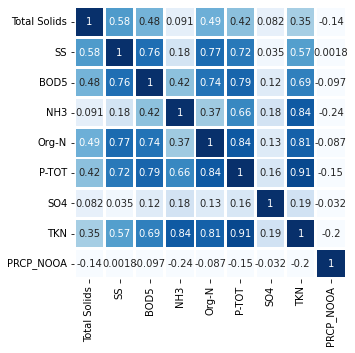

In [ ]:
corr = water_new.corr()
plt.figure(figsize=(5,5))
ax = sns.heatmap(corr, cbar=0, linewidths=2,vmax=1, vmin=0, square=True, cmap='Blues', annot=True)
plt.show()

### pair plot of the data

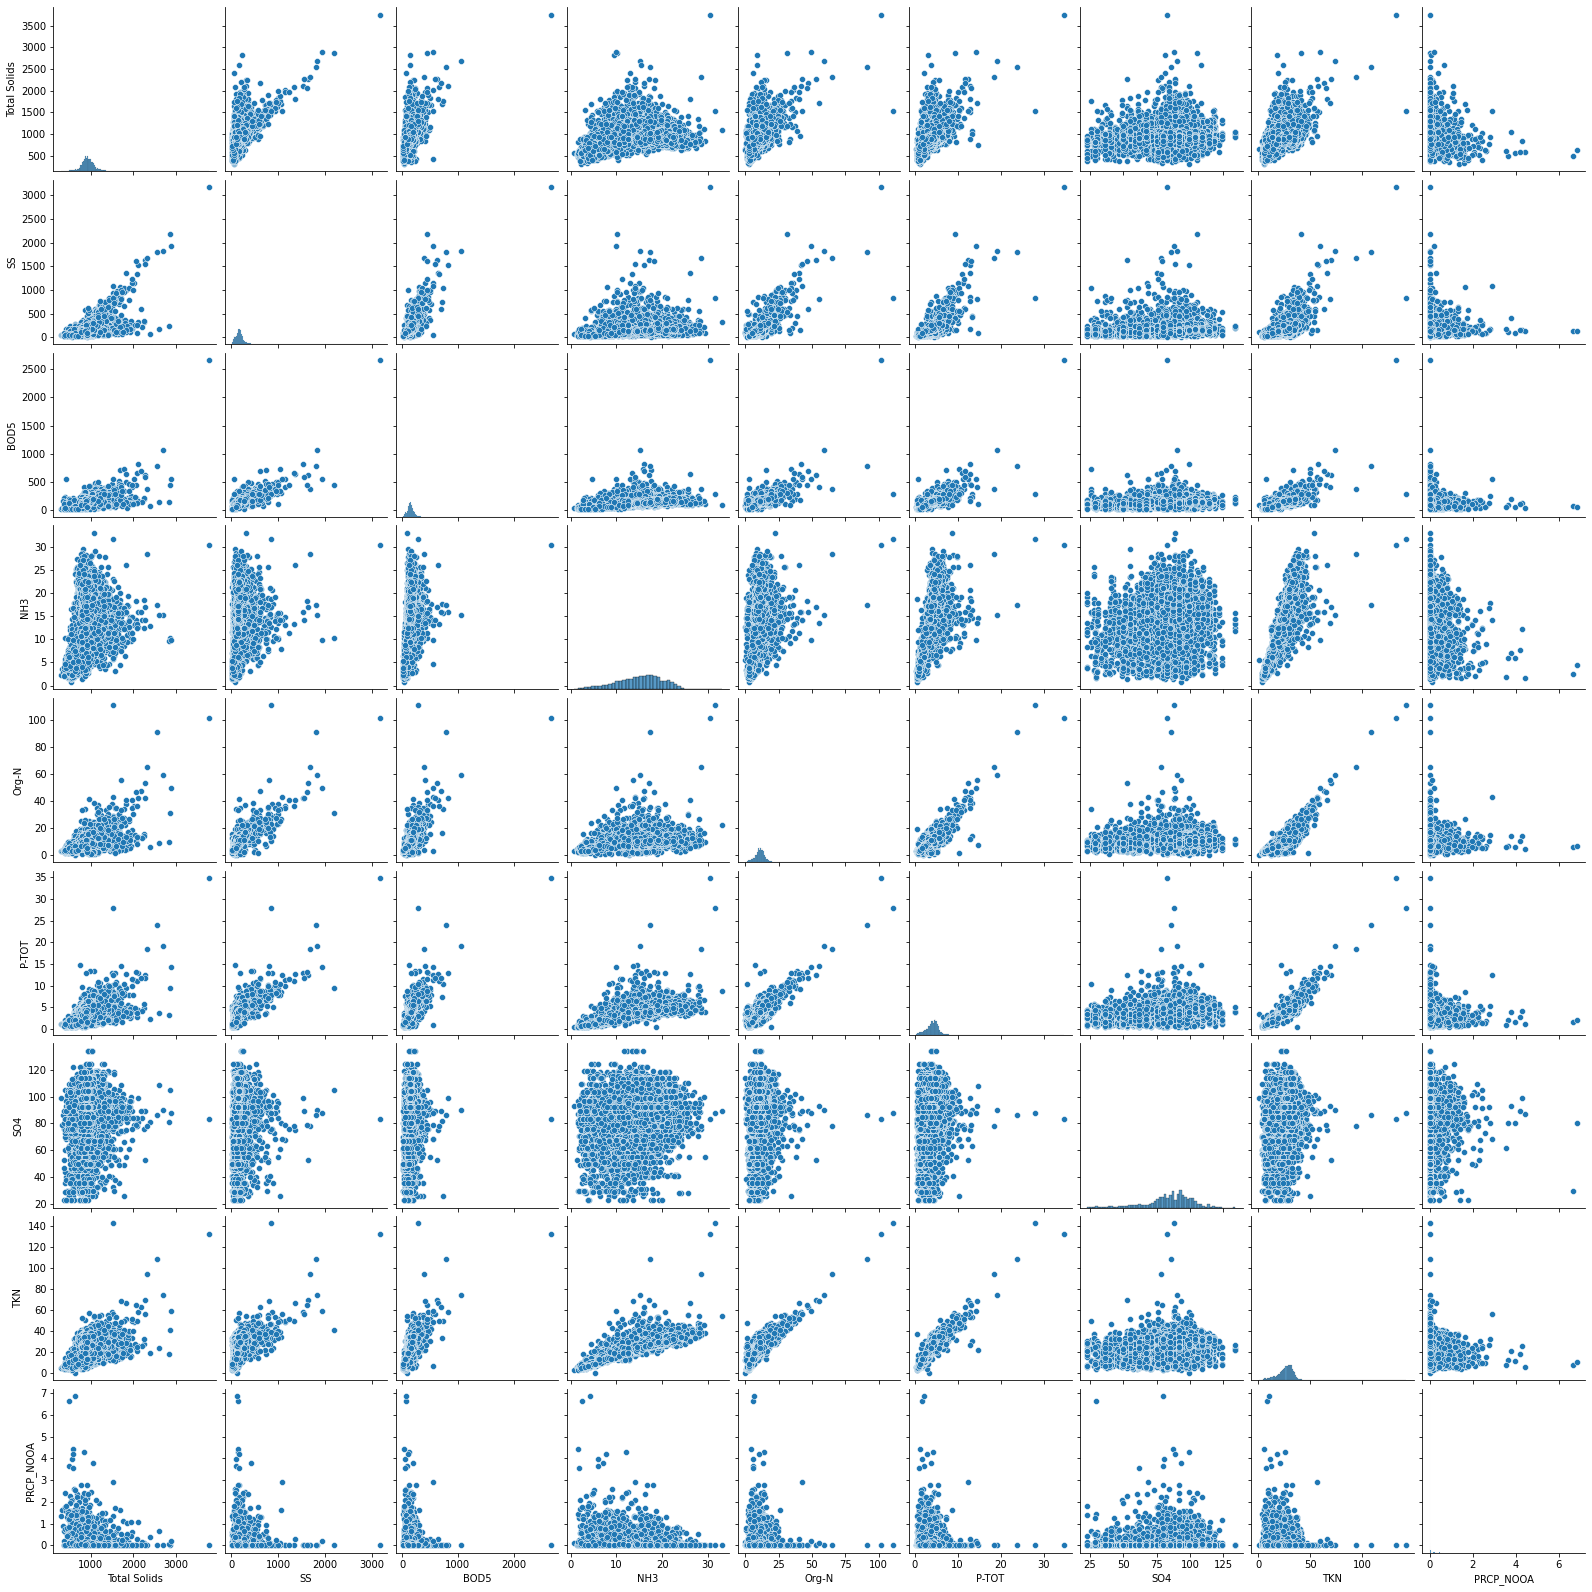

In [ ]:
g = sns.pairplot(water_new)
plt.show()

### P-TOT, TKN, Org-N are linearly correlated

### Non of them are normaly distributed ethier they are positively skewed or negatively skewed 


# Data Scaling


In [ ]:
from sklearn.preprocessing import StandardScaler
def scalingData(data):
 scaler  = StandardScaler()
 data = scaler.fit_transform(data)
 return data


## Model for all columns and checking for the model performance. five models: Linear Regression, Support Vector Regression, Random Forest Regression, Ridge regressor, Gradient Boosting Regressor.

In [ ]:
columns = ['Total Solids', 'SS', 'BOD5', 'NH3', 'Org-N', 'P-TOT', 'SO4', 'TKN', 'PRCP_NOOA']

Building Random Forest model for predictor:  Total Solids 
no of trees:  25
feature importance values {'SS': 0.3455671806235797, 'BOD5': 0.08315684394468287, 'NH3': 0.11539547783573235, 'Org-N': 0.07670213976901835, 'P-TOT': 0.06508241039110894, 'SO4': 0.07068251501574106, 'TKN': 0.16598668402315173, 'PRCP_NOOA': 0.077426748396985}
r2_score of the model 0.40403962787485936
Mean Squared Error of the model 29386.7346174284


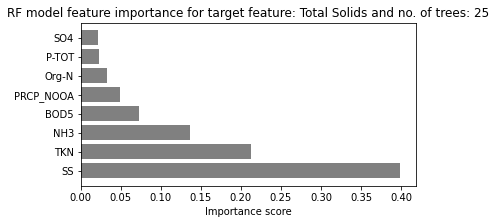

no of trees:  50
feature importance values {'SS': 0.3476297273891983, 'BOD5': 0.08248421927844868, 'NH3': 0.11320161343068247, 'Org-N': 0.07679502712794316, 'P-TOT': 0.06723310416940029, 'SO4': 0.07035752214014684, 'TKN': 0.16334388611054337, 'PRCP_NOOA': 0.07895490035363692}
r2_score of the model 0.40662519738549174
Mean Squared Error of the model 29259.24049433272


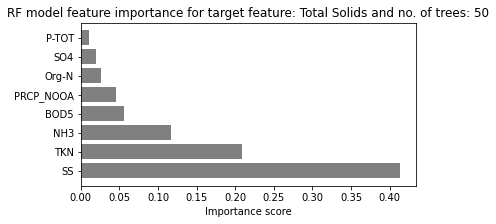

no of trees:  100
feature importance values {'SS': 0.3476347837062772, 'BOD5': 0.08435860484001745, 'NH3': 0.11129313614661028, 'Org-N': 0.0783103601267499, 'P-TOT': 0.06628120357566974, 'SO4': 0.07124242556391158, 'TKN': 0.16157090509749744, 'PRCP_NOOA': 0.07930858094326636}
r2_score of the model 0.4122705686576025
Mean Squared Error of the model 28980.86791261426


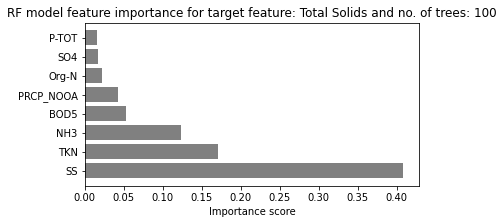

no of trees:  500
feature importance values {'SS': 0.34322387680536326, 'BOD5': 0.08341805008313488, 'NH3': 0.11215636868035136, 'Org-N': 0.07968059213948894, 'P-TOT': 0.06468584990940135, 'SO4': 0.07195448834988563, 'TKN': 0.1646993346389362, 'PRCP_NOOA': 0.08018143939343834}
r2_score of the model 0.4171910967109602
Mean Squared Error of the model 28738.237263254112


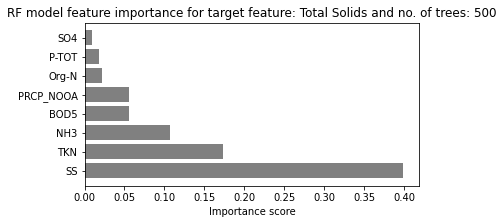

Building Random Forest model for predictor:  SS 
no of trees:  25
feature importance values {'Total Solids': 0.22487234051824498, 'BOD5': 0.18903138923062354, 'NH3': 0.03405358462020846, 'Org-N': 0.41522829676828604, 'P-TOT': 0.07854126106388229, 'SO4': 0.023536362499355173, 'TKN': 0.021811876167513178, 'PRCP_NOOA': 0.01292488913188625}
r2_score of the model 0.845462644168389
Mean Squared Error of the model 2769.663950274223


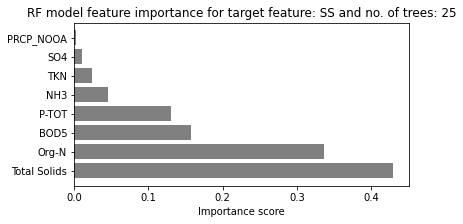

no of trees:  50
feature importance values {'Total Solids': 0.2353599091952914, 'BOD5': 0.17252893745226902, 'NH3': 0.03462968928246238, 'Org-N': 0.41684507499369955, 'P-TOT': 0.08148177229441926, 'SO4': 0.024323290424810202, 'TKN': 0.021726435321929163, 'PRCP_NOOA': 0.013104891035119073}
r2_score of the model 0.8547349706394941
Mean Squared Error of the model 2603.482587690433


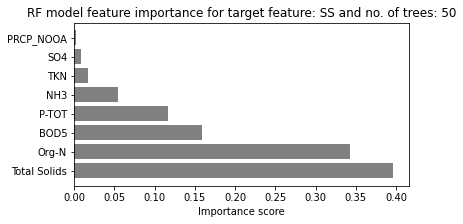

no of trees:  100
feature importance values {'Total Solids': 0.2406584678567488, 'BOD5': 0.1638967072258293, 'NH3': 0.03513091650931206, 'Org-N': 0.4229142589369524, 'P-TOT': 0.07410838552044104, 'SO4': 0.023271701725479543, 'TKN': 0.026899997547368736, 'PRCP_NOOA': 0.0131195646778682}
r2_score of the model 0.8570734847086807
Mean Squared Error of the model 2561.571050639854


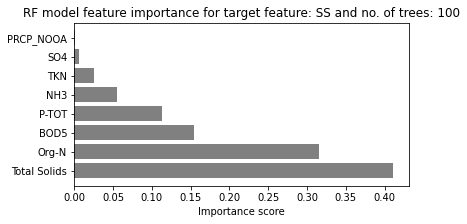

no of trees:  500
feature importance values {'Total Solids': 0.23696343683652935, 'BOD5': 0.1602627674199412, 'NH3': 0.034715384123494064, 'Org-N': 0.41662546240975745, 'P-TOT': 0.08976528734120337, 'SO4': 0.022771618774794642, 'TKN': 0.025877219074984047, 'PRCP_NOOA': 0.013018824019295973}
r2_score of the model 0.8594087811858792
Mean Squared Error of the model 2519.717180219379


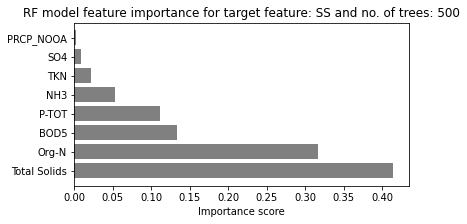

Building Random Forest model for predictor:  BOD5 
no of trees:  25
feature importance values {'Total Solids': 0.07317929161514651, 'SS': 0.19914514698700916, 'NH3': 0.040109554207000936, 'Org-N': 0.0767778860787848, 'P-TOT': 0.5194783348638013, 'SO4': 0.032905735849077626, 'TKN': 0.050417032759858864, 'PRCP_NOOA': 0.007987017639320896}
r2_score of the model 0.722828692313428
Mean Squared Error of the model 1252.9239780621572


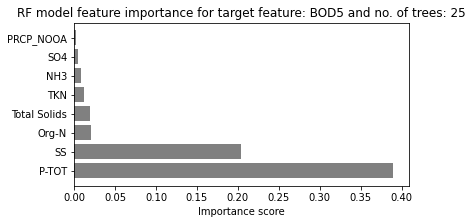

no of trees:  50
feature importance values {'Total Solids': 0.0807218981634761, 'SS': 0.20427824702669262, 'NH3': 0.03477963725343875, 'Org-N': 0.06566804649522102, 'P-TOT': 0.5353191990425336, 'SO4': 0.03317330573007446, 'TKN': 0.037403925695028255, 'PRCP_NOOA': 0.008655740593535289}
r2_score of the model 0.7230505155019668
Mean Squared Error of the model 1251.921249482023


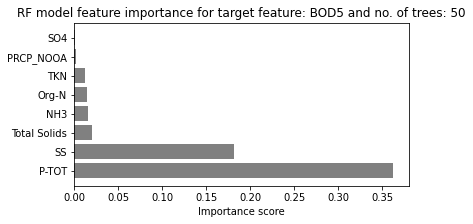

no of trees:  100
feature importance values {'Total Solids': 0.09332555965971179, 'SS': 0.2176016697377876, 'NH3': 0.031999207354956025, 'Org-N': 0.06963111654009134, 'P-TOT': 0.510940495396463, 'SO4': 0.031649869422008745, 'TKN': 0.03665069532969935, 'PRCP_NOOA': 0.008201386559282108}
r2_score of the model 0.7259109309708798
Mean Squared Error of the model 1238.9910397928093


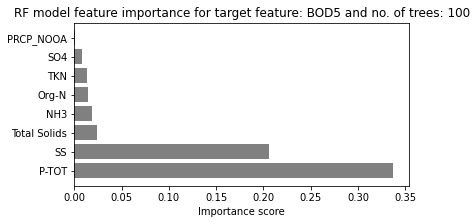

no of trees:  500
feature importance values {'Total Solids': 0.09134137406063765, 'SS': 0.2119594071770411, 'NH3': 0.033974880906183884, 'Org-N': 0.07606359645065243, 'P-TOT': 0.5078577841924156, 'SO4': 0.03093705372982419, 'TKN': 0.03968485960716426, 'PRCP_NOOA': 0.008181043876081014}
r2_score of the model 0.721903989690181
Mean Squared Error of the model 1257.1039997928094


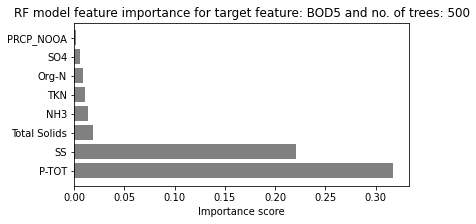

Building Random Forest model for predictor:  NH3 
no of trees:  25
feature importance values {'Total Solids': 0.0024834953121633174, 'SS': 0.0016635843383474608, 'BOD5': 0.001514811783109876, 'Org-N': 0.145265737141443, 'P-TOT': 0.0020802352137900813, 'SO4': 0.0009173198467532797, 'TKN': 0.8456855832067393, 'PRCP_NOOA': 0.0003892331576537982}
r2_score of the model 0.9886258731224175
Mean Squared Error of the model 0.3069445024253505


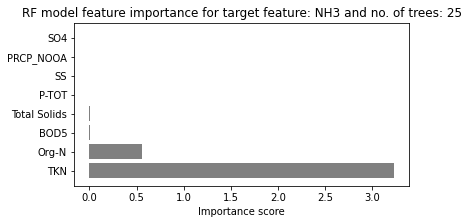

no of trees:  50
feature importance values {'Total Solids': 0.002547666546557407, 'SS': 0.0017961237500243124, 'BOD5': 0.0015051456508314675, 'Org-N': 0.14568288469334223, 'P-TOT': 0.0019046625354144225, 'SO4': 0.0010525166512742224, 'TKN': 0.8450724385443141, 'PRCP_NOOA': 0.0004385616282418838}
r2_score of the model 0.9888221122301908
Mean Squared Error of the model 0.30164875393053


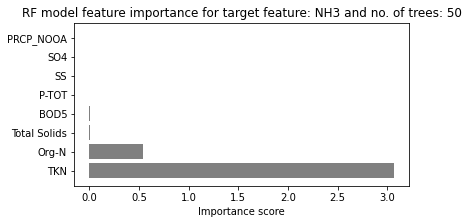

no of trees:  100
feature importance values {'Total Solids': 0.002366190059050653, 'SS': 0.002084078240600311, 'BOD5': 0.0015747890272165717, 'Org-N': 0.1470939986389018, 'P-TOT': 0.0018161751552832285, 'SO4': 0.0010831282949319567, 'TKN': 0.8435113216536563, 'PRCP_NOOA': 0.0004703189303592263}
r2_score of the model 0.9889981449856194
Mean Squared Error of the model 0.2968982981718462


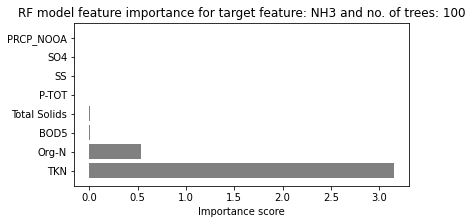

no of trees:  500
feature importance values {'Total Solids': 0.0024329238935738395, 'SS': 0.00204757067183331, 'BOD5': 0.0018882397346992048, 'Org-N': 0.1464789158811008, 'P-TOT': 0.002074911206052764, 'SO4': 0.0010768208549657176, 'TKN': 0.8435474749702432, 'PRCP_NOOA': 0.0004531427875311384}
r2_score of the model 0.9885416651884491
Mean Squared Error of the model 0.30921695486678796


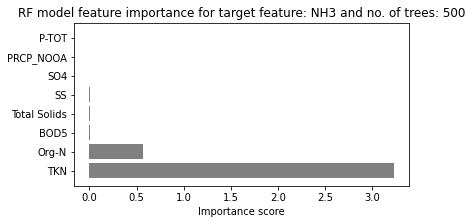

Building Random Forest model for predictor:  Org-N 
no of trees:  25
feature importance values {'Total Solids': 0.010032980512294445, 'SS': 0.119524050980941, 'BOD5': 0.004772283516461204, 'NH3': 0.10190488696140097, 'P-TOT': 0.19125853829440737, 'SO4': 0.004186784000363847, 'TKN': 0.5672836192934246, 'PRCP_NOOA': 0.0010368564407066026}
r2_score of the model 0.9444291075049163
Mean Squared Error of the model 1.2191921909079833


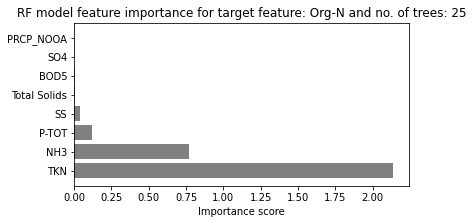

no of trees:  50
feature importance values {'Total Solids': 0.00863945825907549, 'SS': 0.1184395514859988, 'BOD5': 0.0047217892914020254, 'NH3': 0.10027390968893049, 'P-TOT': 0.18809922137617846, 'SO4': 0.003987637250489628, 'TKN': 0.5746813423532916, 'PRCP_NOOA': 0.001157090294633523}
r2_score of the model 0.9460876896551831
Mean Squared Error of the model 1.1828038891407675


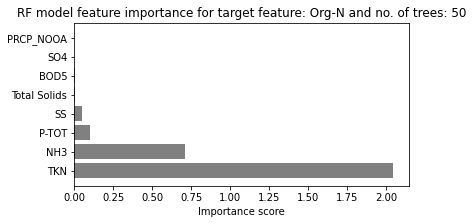

no of trees:  100
feature importance values {'Total Solids': 0.009187438722057245, 'SS': 0.12324160902144261, 'BOD5': 0.0047789794020467145, 'NH3': 0.09654519534310804, 'P-TOT': 0.20027929671850755, 'SO4': 0.004455159903602707, 'TKN': 0.5603183232339068, 'PRCP_NOOA': 0.0011939976553283188}
r2_score of the model 0.9490812170797526
Mean Squared Error of the model 1.1171276853686771


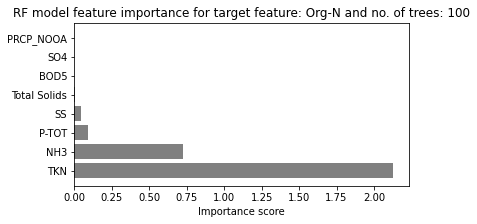

no of trees:  500
feature importance values {'Total Solids': 0.009119906733551196, 'SS': 0.12060275077816382, 'BOD5': 0.005493263476195934, 'NH3': 0.09472133497347936, 'P-TOT': 0.22235893075765292, 'SO4': 0.004481194126645273, 'TKN': 0.5421117994885363, 'PRCP_NOOA': 0.0011108196657753308}
r2_score of the model 0.9472785793032741
Mean Squared Error of the model 1.1566764815358928


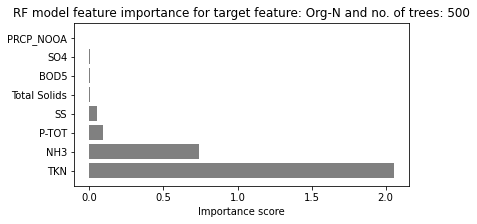

Building Random Forest model for predictor:  P-TOT 
no of trees:  25
feature importance values {'Total Solids': 0.016783157058258683, 'SS': 0.041692738853911095, 'BOD5': 0.05941259254367422, 'NH3': 0.01876563551625567, 'Org-N': 0.10914855965400061, 'SO4': 0.010286813287181337, 'TKN': 0.7403989181067213, 'PRCP_NOOA': 0.003511584979997203}
r2_score of the model 0.8810760463689681
Mean Squared Error of the model 0.308040856258379


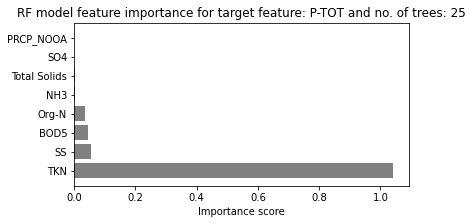

no of trees:  50
feature importance values {'Total Solids': 0.020216624505563927, 'SS': 0.04018033660024999, 'BOD5': 0.05653786178722731, 'NH3': 0.020415618667090976, 'Org-N': 0.13072033021602478, 'SO4': 0.01117515096071946, 'TKN': 0.7173235438426712, 'PRCP_NOOA': 0.0034305334204523083}
r2_score of the model 0.882866260646733
Mean Squared Error of the model 0.3034037825472272


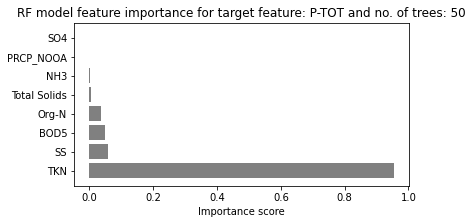

no of trees:  100
feature importance values {'Total Solids': 0.02121215939071653, 'SS': 0.0408588294255813, 'BOD5': 0.05481773618365572, 'NH3': 0.018172823832771346, 'Org-N': 0.15603862454728826, 'SO4': 0.011306614080234091, 'TKN': 0.6941738357750293, 'PRCP_NOOA': 0.0034193767647234174}
r2_score of the model 0.8824076535791351
Mean Squared Error of the model 0.30459168212065807


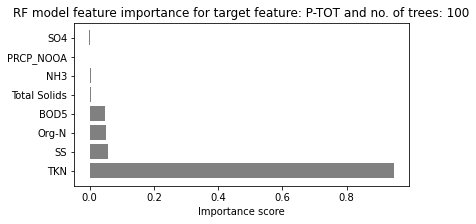

no of trees:  500
feature importance values {'Total Solids': 0.01857526940798707, 'SS': 0.04414570339909232, 'BOD5': 0.05523742985991125, 'NH3': 0.01622149174167193, 'Org-N': 0.15259084021792851, 'SO4': 0.011247353922952305, 'TKN': 0.6986584710441344, 'PRCP_NOOA': 0.003323440406322249}
r2_score of the model 0.8839351508225092
Mean Squared Error of the model 0.300635106978184


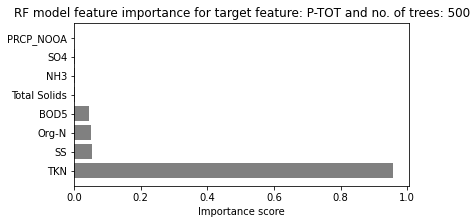

Building Random Forest model for predictor:  SO4 
no of trees:  25
feature importance values {'Total Solids': 0.14243731416298994, 'SS': 0.14409190668262636, 'BOD5': 0.14401539028362734, 'NH3': 0.16848876228744764, 'Org-N': 0.11148367842427392, 'P-TOT': 0.12189612256057818, 'TKN': 0.1149534255676696, 'PRCP_NOOA': 0.05263340003078695}
r2_score of the model 0.043929168441539934
Mean Squared Error of the model 262.96530575015237


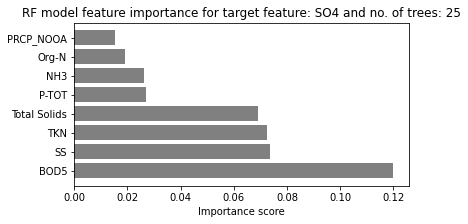

no of trees:  50
feature importance values {'Total Solids': 0.14172761598197267, 'SS': 0.14230970496405548, 'BOD5': 0.14539365431147247, 'NH3': 0.16863472973797175, 'Org-N': 0.1114384382559373, 'P-TOT': 0.1231421353650047, 'TKN': 0.11280330959427902, 'PRCP_NOOA': 0.05455041178930659}
r2_score of the model 0.06298103478062145
Mean Squared Error of the model 257.7251292992078


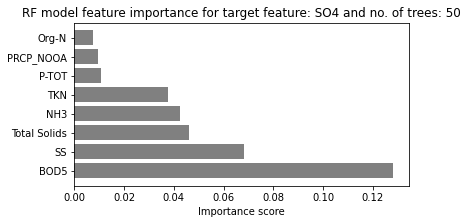

no of trees:  100
feature importance values {'Total Solids': 0.13988938416875235, 'SS': 0.1426532288175157, 'BOD5': 0.14469422520445882, 'NH3': 0.16566926261323442, 'Org-N': 0.11241705693687803, 'P-TOT': 0.12416875182160136, 'TKN': 0.11493179883614153, 'PRCP_NOOA': 0.055576291601417784}
r2_score of the model 0.07420385695975806
Mean Squared Error of the model 254.63831525959782


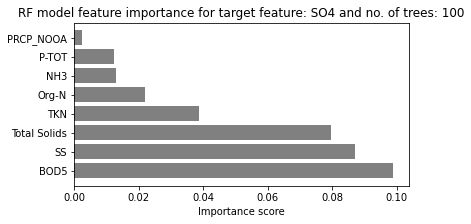

no of trees:  500
feature importance values {'Total Solids': 0.1401651183431948, 'SS': 0.14114417859038353, 'BOD5': 0.1436478282513525, 'NH3': 0.1683902567337674, 'Org-N': 0.1113101285019446, 'P-TOT': 0.12474965824218257, 'TKN': 0.11476954874596071, 'PRCP_NOOA': 0.05582328259121383}
r2_score of the model 0.08582846573694647
Mean Squared Error of the model 251.4409906468007


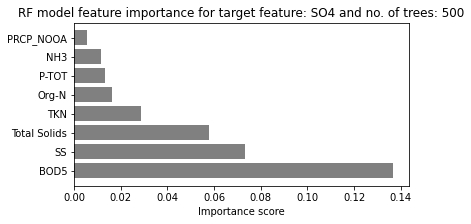

Building Random Forest model for predictor:  TKN 
no of trees:  25
feature importance values {'Total Solids': 0.0017976831877490112, 'SS': 0.0012578506942795965, 'BOD5': 0.001011010639634527, 'NH3': 0.17874389430212356, 'Org-N': 0.12040278960192685, 'P-TOT': 0.6955036133492245, 'SO4': 0.0009568466406350487, 'PRCP_NOOA': 0.0003263115844269545}
r2_score of the model 0.9895807639315966
Mean Squared Error of the model 0.6958315272151133


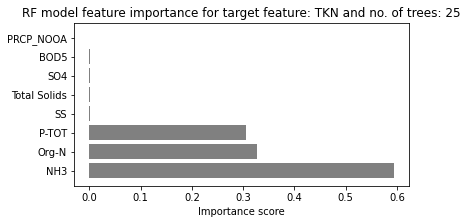

no of trees:  50
feature importance values {'Total Solids': 0.0014967109667796787, 'SS': 0.0013688879376718738, 'BOD5': 0.000925551229613157, 'NH3': 0.17516281582999021, 'Org-N': 0.12300949107793156, 'P-TOT': 0.696798613474018, 'SO4': 0.0009285262665715273, 'PRCP_NOOA': 0.0003094032174239131}
r2_score of the model 0.9908711239547582
Mean Squared Error of the model 0.6096569574405858


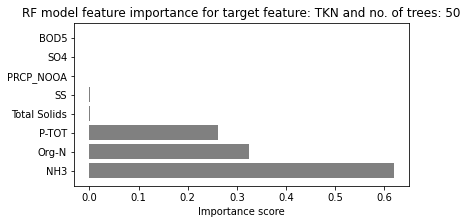

no of trees:  100
feature importance values {'Total Solids': 0.002781082193127685, 'SS': 0.0013122627407309185, 'BOD5': 0.0009310088493578383, 'NH3': 0.17123031251011336, 'Org-N': 0.12403774412970177, 'P-TOT': 0.6983051127817327, 'SO4': 0.0011175050771388883, 'PRCP_NOOA': 0.0002849717180968181}
r2_score of the model 0.9915940640624626
Mean Squared Error of the model 0.5613765925533206


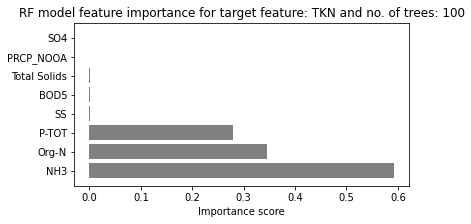

no of trees:  500
feature importance values {'Total Solids': 0.002241304806051609, 'SS': 0.0032053495017530633, 'BOD5': 0.0014908928285420242, 'NH3': 0.16973730788801486, 'Org-N': 0.12189100427883941, 'P-TOT': 0.7000936415523612, 'SO4': 0.0010613569068509798, 'PRCP_NOOA': 0.0002791422375869274}
r2_score of the model 0.9914861575511755
Mean Squared Error of the model 0.5685829512587469


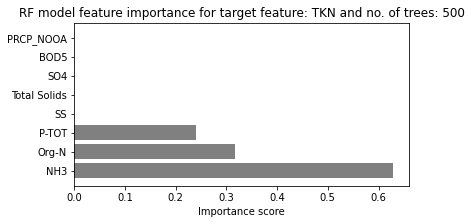

Building Random Forest model for predictor:  PRCP_NOOA 
no of trees:  25
feature importance values {'Total Solids': 0.24213140073974557, 'SS': 0.2195737346723832, 'BOD5': 0.09523810327061114, 'NH3': 0.14603345518602284, 'Org-N': 0.052399418160171074, 'P-TOT': 0.07199814518614546, 'SO4': 0.08528962956009535, 'TKN': 0.0873361132248254}
r2_score of the model -0.10607932111908402
Mean Squared Error of the model 0.06875883397928093


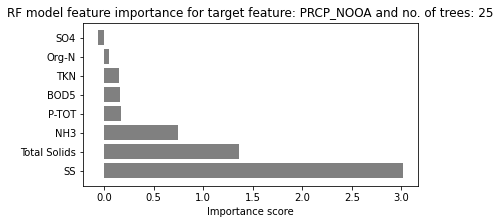

no of trees:  50
feature importance values {'Total Solids': 0.2331600119392585, 'SS': 0.21905791206153885, 'BOD5': 0.10594703013121803, 'NH3': 0.14345105974951264, 'Org-N': 0.06256546193003479, 'P-TOT': 0.07110766545527519, 'SO4': 0.08599032087767085, 'TKN': 0.07872053785549116}
r2_score of the model -0.04685520599059889
Mean Squared Error of the model 0.06507719829372334


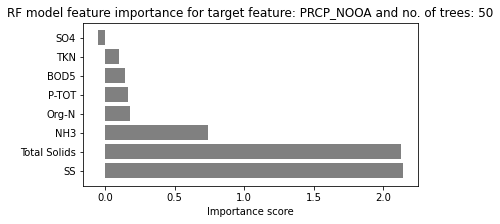

no of trees:  100
feature importance values {'Total Solids': 0.23029641770410522, 'SS': 0.21769476780960786, 'BOD5': 0.10677741601480191, 'NH3': 0.15294693404847445, 'Org-N': 0.06033764658581942, 'P-TOT': 0.07541880396546614, 'SO4': 0.08155904329001552, 'TKN': 0.07496897058170954}
r2_score of the model -0.0449254439588469
Mean Squared Error of the model 0.06495723566118221


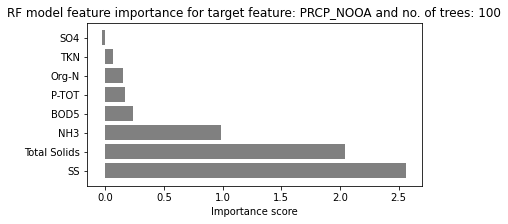

no of trees:  500
feature importance values {'Total Solids': 0.2324221436693185, 'SS': 0.2180454284381138, 'BOD5': 0.10989485104159337, 'NH3': 0.1468477783489567, 'Org-N': 0.061124342133482355, 'P-TOT': 0.07432038398664391, 'SO4': 0.0842819618567658, 'TKN': 0.07306311052512561}
r2_score of the model -0.03641663298781417
Mean Squared Error of the model 0.06442828994296157


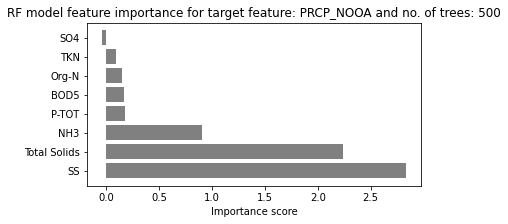

In [ ]:
index = 0
for j in columns:

    print('\033[1m' + 'Building Random Forest model for predictor: ', j, '\033[0m')
    # create target and features for model training
    label = water_new[j]
    train = water_new.drop(columns=[j])
    col = columns.copy()
    col.pop(index)
    # test and train split with split ratio of 25:75
    X_train, X_test, y_train, y_test = train_test_split(train, label, test_size= 0.25, random_state=32)
    for i in [25, 50, 100, 500]:
        print('no of trees: ', i)
        rf = RandomForestRegressor(n_estimators=i,random_state = 32)
        rf.fit(X_train, y_train)
        print('feature importance values' , dict(zip(col,rf.feature_importances_)))
        print('r2_score of the model', r2_score(y_test,rf.predict(X_test)))
        print('Mean Squared Error of the model', mean_squared_error(y_test,rf.predict(X_test)))
        imp = rfpimp.importances(rf, X_test, y_test)
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.barh(imp.index, imp['Importance'], height=0.8, facecolor='grey')
        ax.set_xlabel('Importance score')
        ax.set_title('RF model feature importance for target feature: ' + str(j) + ' and no. of trees: ' + str(i))
        plt.show()
    index = index + 1

In [ ]:
from sklearn.linear_model import LinearRegression

Building Linear Regression model for predictor:  Total Solids 
feature coefficient values {'Total Solids': 109.33659936576132, 'SS': 25.267112940279205, 'BOD5': -88.10607643198179, 'NH3': -30.77714465665263, 'Org-N': -48.15988431875376, 'P-TOT': 11.434058013869572, 'SO4': 129.1935508791534, 'TKN': -31.93492637024397}
r2_score of the model 0.3687436116306131
Mean Squared Error of the model 31127.17695375929


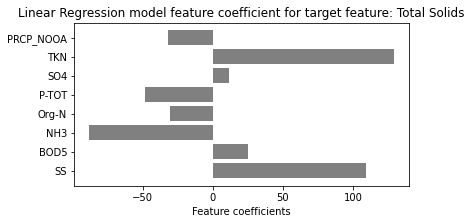

Building Linear Regression model for predictor:  SS 
feature coefficient values {'Total Solids': 25.521008840353048, 'SS': 39.51496461883214, 'BOD5': -43.98948706549741, 'NH3': 20.650316802788765, 'Org-N': 65.85665976879498, 'P-TOT': -7.500322107735332, 'SO4': 1.7400441798555448, 'TKN': 9.027738620174066}
r2_score of the model 0.7717648535933305
Mean Squared Error of the model 4090.497432070126


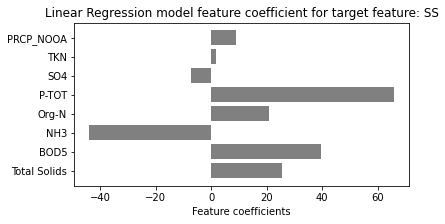

Building Linear Regression model for predictor:  BOD5 
feature coefficient values {'Total Solids': 3.9290973717095006, 'SS': 26.324885550595887, 'BOD5': 3.5086433241179398, 'NH3': 3.615997750951154, 'Org-N': 37.400305895983735, 'P-TOT': 1.9728024814163962, 'SO4': -7.0050763787585915, 'TKN': -1.0513120988430789}
r2_score of the model 0.69285049429808
Mean Squared Error of the model 1388.437294451307


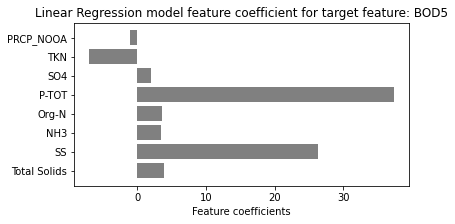

Building Linear Regression model for predictor:  NH3 
feature coefficient values {'Total Solids': -0.08040625105900931, 'SS': -0.17198896153018106, 'BOD5': 0.020591406092905065, 'NH3': -4.328854446234471, 'Org-N': -0.12020934923442976, 'P-TOT': -0.034870391801981156, 'SO4': 8.040226562955654, 'TKN': -0.016344178491204404}
r2_score of the model 0.9836623691062615
Mean Squared Error of the model 0.44089063182258637


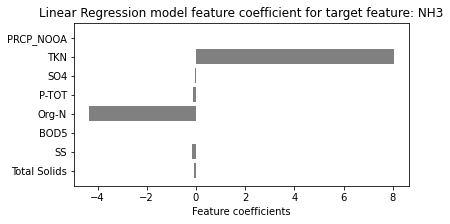

Building Linear Regression model for predictor:  Org-N 
feature coefficient values {'Total Solids': -0.03220609786868563, 'SS': 0.09257723923097583, 'BOD5': 0.02433328619636932, 'NH3': -4.963623291389579, 'Org-N': -0.030769817783185882, 'P-TOT': -0.03402789518337268, 'SO4': 8.103314111843158, 'TKN': 0.008620193675121013}
r2_score of the model 0.9791256169535574
Mean Squared Error of the model 0.4579714965437409


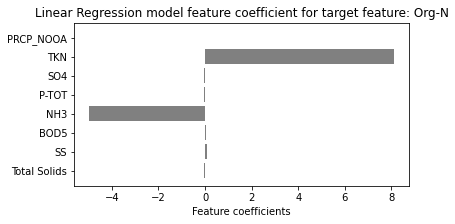

Building Linear Regression model for predictor:  P-TOT 
feature coefficient values {'Total Solids': -0.05520791308933364, 'SS': 0.3234322481232357, 'BOD5': 0.2757108643845753, 'NH3': -0.1509976504445551, 'Org-N': -0.03370784882326072, 'P-TOT': 0.0009863013413292099, 'SO4': 1.2666062433806198, 'TKN': -0.009767335672905955}
r2_score of the model 0.8752989592326865
Mean Squared Error of the model 0.3230048632040335


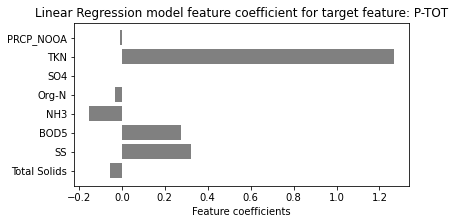

Building Linear Regression model for predictor:  SO4 
feature coefficient values {'Total Solids': 1.306975266736847, 'SS': -3.672946620978366, 'BOD5': 1.4501516231546492, 'NH3': -4.367569783214406, 'Org-N': -3.7169976067018657, 'P-TOT': 0.09834690695360915, 'SO4': 10.368258706999566, 'TKN': 0.513185498409355}
r2_score of the model 0.060143627553121526
Mean Squared Error of the model 258.50555229140485


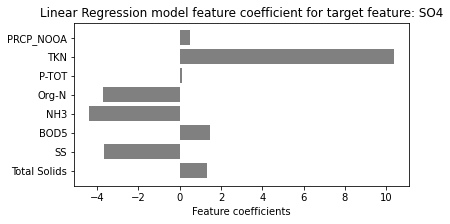

Building Linear Regression model for predictor:  TKN 
feature coefficient values {'Total Solids': 0.0721360322953305, 'SS': 0.004162357854597953, 'BOD5': -0.025152845368247356, 'NH3': 4.919214394079086, 'Org-N': 4.323787160300423, 'P-TOT': 0.6169317832550361, 'SO4': 0.05064659625733933, 'TKN': -0.010632143728702081}
r2_score of the model 0.9931030797334647
Mean Squared Error of the model 0.46059946531948665


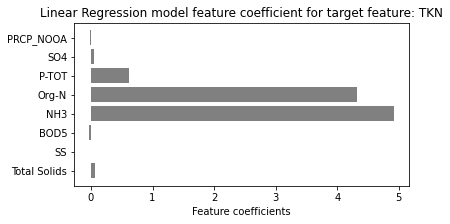

Building Linear Regression model for predictor:  PRCP_NOOA 
feature coefficient values {'Total Solids': -0.07678954153037629, 'SS': 0.09299998021024329, 'BOD5': -0.016256634733860666, 'NH3': -0.04306409252259153, 'Org-N': 0.01980812629655362, 'P-TOT': -0.02048784940225617, 'SO4': 0.010795519678999037, 'TKN': -0.04578735730881946}
r2_score of the model 0.051842291438720434
Mean Squared Error of the model 0.05894172074673606


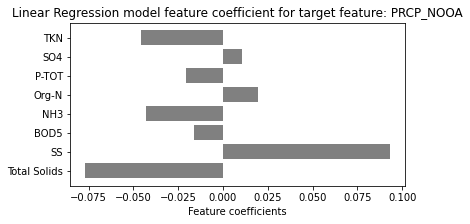

In [ ]:
index = 0
for j in columns:
    print('\033[1m' + 'Building Linear Regression model for predictor: ', j, '\033[0m')
    # create target and features for model training
    label = water_new[j]
    train = water_new.drop(columns=[j])
    col = columns.copy()
    col.pop(index)
    train = scalingData(train)
    # test and train split with split ratio of 25:75
    X_train, X_test, y_train, y_test = train_test_split(train, label, test_size= 0.25, random_state=32)
    lr = LinearRegression()  
    lr.fit(X_train, y_train)
    print('feature coefficient values' , dict(zip(columns,lr.coef_)))
    print('r2_score of the model', r2_score(y_test,lr.predict(X_test)))
    print('Mean Squared Error of the model', mean_squared_error(y_test,lr.predict(X_test)))
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh(col, lr.coef_, height=0.8, facecolor='grey')
    ax.set_xlabel('Feature coefficients')
    ax.set_title('Linear Regression model feature coefficient for target feature: ' + str(j))
    plt.show()
    index = index + 1

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
index = 0
for j in columns:
    print('\033[1m' + 'Building Ridge regressor model for predictor: ', j, '\033[0m')
    # create target and features for model training
    label = water_new[j]
    train = water_new.drop(columns=[j])
    col = columns.copy()
    col.pop(index)
    # test and train split with split ratio of 25:75
    X_train, X_test, y_train, y_test = train_test_split(train, label, test_size= 0.25, random_state=32)
    # Hyperparameter tunning
    ridge = Ridge()
    parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
    ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
   
    ridge_regressor.fit(X_train,y_train)
    print("The best learning rate for the predictor: ", columns[index], " is: ", ridge_regressor.best_params_)
    print(ridge_regressor)

    print('r2_score of the model', r2_score(y_test, ridge_regressor.predict(X_test)))
    print('Mean Squared Error of the model', mean_squared_error(y_test, ridge_regressor.predict(X_test)))
   
    index = index + 1


Building Ridge regressor model for predictor:  Total Solids 
The best learning rate for the predictor:  Total Solids  is:  {'alpha': 30}
GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   20, 30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')
r2_score of the model 0.36878027704103356
Mean Squared Error of the model 31125.368986760037
Building Ridge regressor model for predictor:  SS 
The best learning rate for the predictor:  SS  is:  {'alpha': 55}
GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   20, 30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')
r2_score of the model 0.7721948794246254
Mean Squared Error of the model 4082.790382624282
Building Ridge regressor model for predictor:  BOD5 
The best learning rate for the predictor:

In [ ]:
from sklearn.svm import SVR

Building Support Vector Regression model for predictor:  Total Solids 
feature coefficient values {'SS': 0.8104642096586758, 'BOD5': 0.20637724597963825, 'NH3': -21.568300830468317, 'Org-N': -8.5250034363192, 'P-TOT': -19.16090427061512, 'SO4': 0.6179507961221447, 'TKN': 16.863714800139984, 'PRCP_NOOA': -81.42485855290832}
r2_score of the model 0.35184606281242037
Mean Squared Error of the model 31960.393063472373


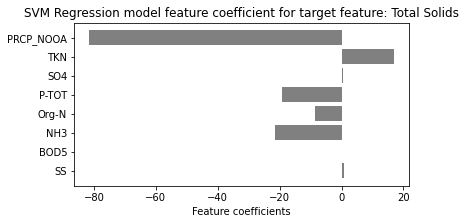

Building Support Vector Regression model for predictor:  SS 
feature coefficient values {'Total Solids': 0.047857295824542234, 'BOD5': 0.44967366188859614, 'NH3': -7.719555986026684, 'Org-N': 4.099824445462531, 'P-TOT': 32.82006199987942, 'SO4': -0.2343264050038556, 'TKN': 1.626516760082822, 'PRCP_NOOA': 20.514961890259443}
r2_score of the model 0.7343155111582681
Mean Squared Error of the model 4761.6755633750645


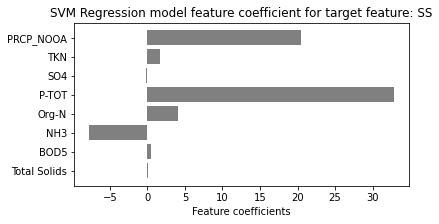

Building Support Vector Regression model for predictor:  BOD5 
feature coefficient values {'Total Solids': 0.01377768973907223, 'SS': 0.16208058008805892, 'NH3': -0.8791508476296492, 'Org-N': 0.6970766223204983, 'P-TOT': 21.911450180713935, 'SO4': 0.05882354083576047, 'TKN': 0.7719513180087532, 'PRCP_NOOA': -2.315015463846271}
r2_score of the model 0.6906284789306941
Mean Squared Error of the model 1398.4816830882744


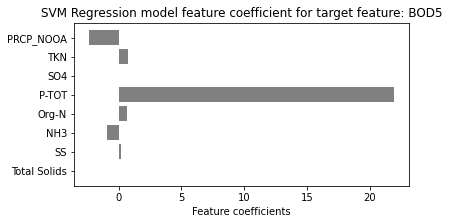

Building Support Vector Regression model for predictor:  NH3 
feature coefficient values {'Total Solids': 0.0009404635002283612, 'SS': 0.0007781456806696951, 'BOD5': 0.0011606714874687896, 'Org-N': -1.0130907417086572, 'P-TOT': 0.02194112468193854, 'SO4': 0.001535192526077367, 'TKN': 0.9893285961578648, 'PRCP_NOOA': -0.019434204470908156}
r2_score of the model 0.9790975395549146
Mean Squared Error of the model 0.5640780509867116


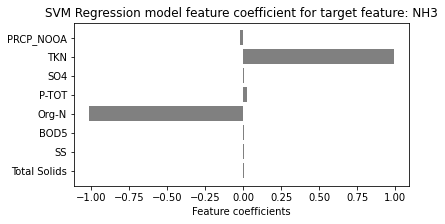

Building Support Vector Regression model for predictor:  Org-N 
feature coefficient values {'Total Solids': 0.0005851454443472903, 'SS': 0.00031894195399218006, 'BOD5': -0.0007971266727508919, 'NH3': -1.007903633744899, 'P-TOT': 0.11146023473774402, 'SO4': -0.0004642503159146827, 'TKN': 0.991310836737096, 'PRCP_NOOA': 0.051612441152288024}
r2_score of the model 0.9772359387414108
Mean Squared Error of the model 0.4994299078834892


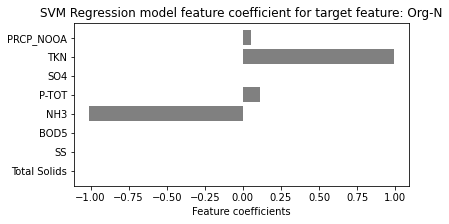

Building Support Vector Regression model for predictor:  P-TOT 
feature coefficient values {'Total Solids': 4.912867936468501e-05, 'SS': 0.0036763366991436897, 'BOD5': 0.005822276409809035, 'NH3': -0.054979158935405614, 'Org-N': -0.08008767600313993, 'SO4': -0.004242585271464705, 'TKN': 0.18015038850820986, 'PRCP_NOOA': -0.01239232094534426}
r2_score of the model 0.85908133398399
Mean Squared Error of the model 0.3650123059063287


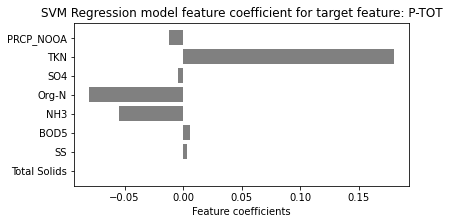

Building Support Vector Regression model for predictor:  SO4 
feature coefficient values {'Total Solids': 0.001998335939788376, 'SS': -0.022279829343005986, 'BOD5': 0.0299770661704315, 'NH3': -1.3289325599686173, 'Org-N': -0.9455669979164227, 'P-TOT': -0.9863794108725665, 'TKN': 1.6421880614531403, 'PRCP_NOOA': 0.7932315430992795}
r2_score of the model 0.037668387189758845
Mean Squared Error of the model 264.68732069064134


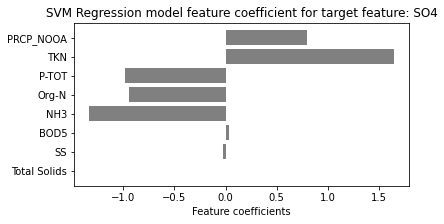

Building Support Vector Regression model for predictor:  TKN 
feature coefficient values {'Total Solids': -2.12854483834235e-05, 'SS': 0.0008625608097645454, 'BOD5': 0.0008743960659103323, 'NH3': 0.9851288052800982, 'Org-N': 1.0180688169927485, 'P-TOT': -0.028327958493941097, 'SO4': -0.0022597179421950386, 'PRCP_NOOA': -0.05717885549350621}
r2_score of the model 0.992145830568287
Mean Squared Error of the model 0.5245277748575419


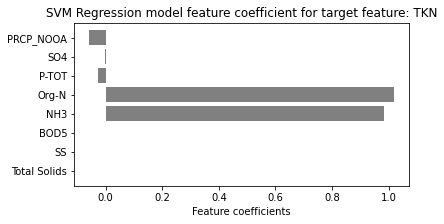

Building Support Vector Regression model for predictor:  PRCP_NOOA 
feature coefficient values {'Total Solids': 0.0002385062543908134, 'SS': 0.00032563600143475924, 'BOD5': 0.001228304054166074, 'NH3': 0.04094003300232174, 'Org-N': 0.06358544347869355, 'P-TOT': -0.037822124311041705, 'SO4': 0.0009121600390358253, 'TKN': -0.06749486645426117}
r2_score of the model -0.29099274893105176
Mean Squared Error of the model 0.08025387908201272


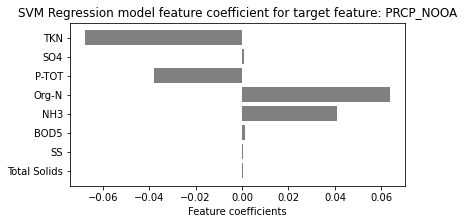

In [ ]:
for j in ['Total Solids', 'SS', 'BOD5', 'NH3', 'Org-N', 'P-TOT', 'SO4', 'TKN', 'PRCP_NOOA']:
    print('\033[1m' + 'Building Support Vector Regression model for predictor: ', j, '\033[0m')
    # create target and features for model training
    label = water_new[j]
    train = water_new.drop(columns=[j])
    # test and train split with split ratio of 25:75
    X_train, X_test, y_train, y_test = train_test_split(train, label, test_size= 0.25, random_state=32)
    lr = SVR(kernel="linear")  
    lr.fit(X_train, y_train)
    print('feature coefficient values' , dict(zip(X_train.columns,lr.coef_[0])))
    print('r2_score of the model', r2_score(y_test,lr.predict(X_test)))
    print('Mean Squared Error of the model', mean_squared_error(y_test,lr.predict(X_test)))
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh(X_train.columns,lr.coef_[0], height=0.8, facecolor='grey')
    ax.set_xlabel('Feature coefficients')
    ax.set_title('SVM Regression model feature coefficient for target feature: ' + str(j))
    plt.show()

Building Gradient Boosting Regressor model for predictor:  Total Solids 
no of trees:  25
feature importance values {'SS': 0.6323981061610837, 'BOD5': 0.026766891967995483, 'NH3': 0.07580769946998377, 'Org-N': 0.0316036167398425, 'P-TOT': 0.007674196646173839, 'SO4': 0.010964386434951122, 'TKN': 0.164775145265855, 'PRCP_NOOA': 0.05000995731411467}
r2_score of the model 0.41301613317350805
Mean Squared Error of the model 28944.10421557353


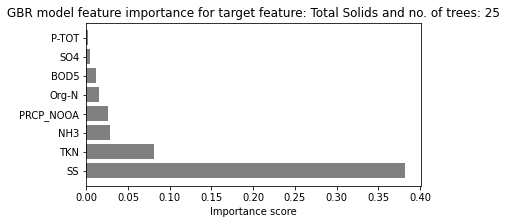

no of trees:  50
feature importance values {'SS': 0.5826259090241027, 'BOD5': 0.03739551368251669, 'NH3': 0.08020310216680471, 'Org-N': 0.03441313636191134, 'P-TOT': 0.01567758118808865, 'SO4': 0.028651145997852075, 'TKN': 0.15999480784336897, 'PRCP_NOOA': 0.061038803735354974}
r2_score of the model 0.4387774921702463
Mean Squared Error of the model 27673.814686889087


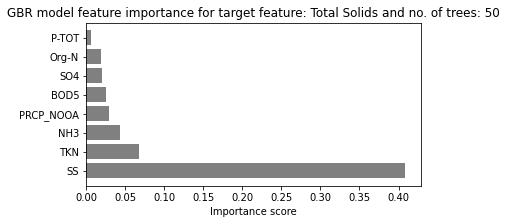

no of trees:  100
feature importance values {'SS': 0.5404354571915779, 'BOD5': 0.042079705140313124, 'NH3': 0.08438169599025011, 'Org-N': 0.038384770158964535, 'P-TOT': 0.021921744449791322, 'SO4': 0.04824082967206958, 'TKN': 0.1617195336916712, 'PRCP_NOOA': 0.06283626370536213}
r2_score of the model 0.45583470903831047
Mean Squared Error of the model 26832.725364747934


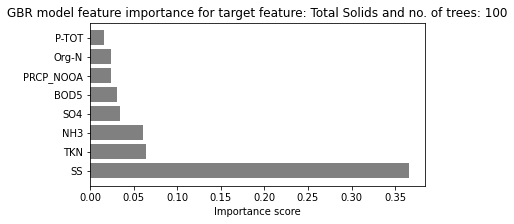

no of trees:  500
feature importance values {'SS': 0.43913629575730784, 'BOD5': 0.059049419723282565, 'NH3': 0.10413218841580507, 'Org-N': 0.05046037905113321, 'P-TOT': 0.040357648985463665, 'SO4': 0.07681246619938117, 'TKN': 0.15805251196848039, 'PRCP_NOOA': 0.07199908989914612}
r2_score of the model 0.4484710280539951
Mean Squared Error of the model 27195.82759270621


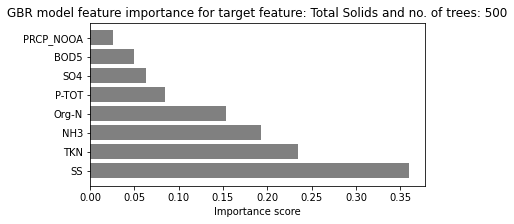

Building Gradient Boosting Regressor model for predictor:  SS 
no of trees:  25
feature importance values {'Total Solids': 0.30385404333122984, 'BOD5': 0.18083591530389068, 'NH3': 0.01261792718172229, 'Org-N': 0.36015216083604734, 'P-TOT': 0.13608794290023363, 'SO4': 0.0007094441789937689, 'TKN': 0.002553730938722002, 'PRCP_NOOA': 0.0031888353291603688}
r2_score of the model 0.8314962340518901
Mean Squared Error of the model 3019.974060773085


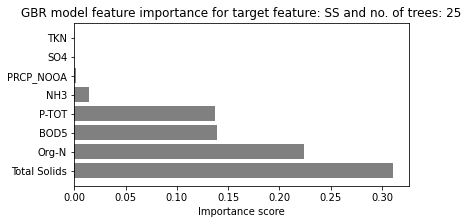

no of trees:  50
feature importance values {'Total Solids': 0.2968930843397132, 'BOD5': 0.17733853684174505, 'NH3': 0.020452315110061264, 'Org-N': 0.3474969488877212, 'P-TOT': 0.14015535479178304, 'SO4': 0.003535596639280087, 'TKN': 0.007525105294488178, 'PRCP_NOOA': 0.006603058095208135}
r2_score of the model 0.84933694164956
Mean Squared Error of the model 2700.2276511445175


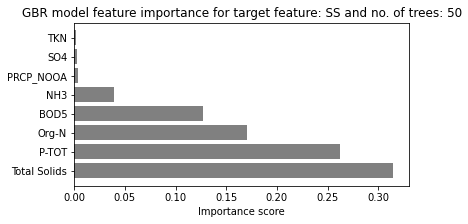

no of trees:  100
feature importance values {'Total Solids': 0.29211324554759843, 'BOD5': 0.1760599519536203, 'NH3': 0.02303051979684071, 'Org-N': 0.34343767572248507, 'P-TOT': 0.14198269075540387, 'SO4': 0.005635053196605737, 'TKN': 0.010545843053618305, 'PRCP_NOOA': 0.007195019973827592}
r2_score of the model 0.8579518437309621
Mean Squared Error of the model 2545.8288418624375


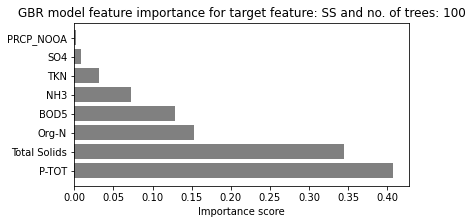

no of trees:  500
feature importance values {'Total Solids': 0.2875359433895349, 'BOD5': 0.1737669563935871, 'NH3': 0.027738901017908282, 'Org-N': 0.3347823391924017, 'P-TOT': 0.1428343013999323, 'SO4': 0.0097094782962683, 'TKN': 0.015200862172898623, 'PRCP_NOOA': 0.008431218137468865}
r2_score of the model 0.8624778746002979
Mean Squared Error of the model 2464.7119852346673


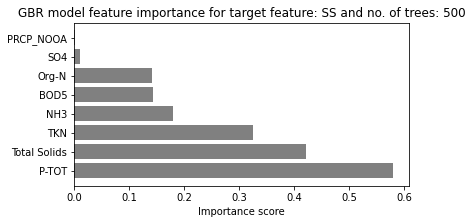

Building Gradient Boosting Regressor model for predictor:  BOD5 
no of trees:  25
feature importance values {'Total Solids': 0.15551865686896707, 'SS': 0.26284329006703755, 'NH3': 0.01400826134100396, 'Org-N': 0.06962553670724157, 'P-TOT': 0.4752726749263742, 'SO4': 0.0009764677801695883, 'TKN': 0.020451891865959214, 'PRCP_NOOA': 0.0013032204432468016}
r2_score of the model 0.6817262066173795
Mean Squared Error of the model 1438.7234762727398


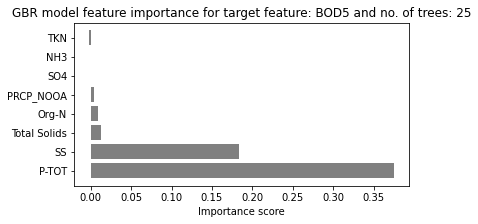

no of trees:  50
feature importance values {'Total Solids': 0.1549692028611579, 'SS': 0.26066247128823433, 'NH3': 0.021582114962504076, 'Org-N': 0.07083325421010327, 'P-TOT': 0.4626621996275988, 'SO4': 0.005205429121372709, 'TKN': 0.022647907731009383, 'PRCP_NOOA': 0.0014374201980195216}
r2_score of the model 0.6935494046911659
Mean Squared Error of the model 1385.277942939338


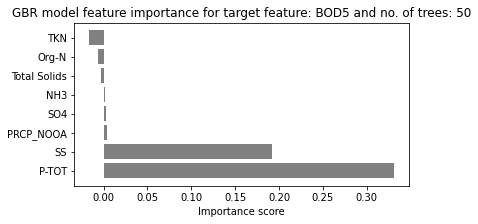

no of trees:  100
feature importance values {'Total Solids': 0.15430599752285332, 'SS': 0.2609523228551687, 'NH3': 0.023691889722269467, 'Org-N': 0.07070722061754123, 'P-TOT': 0.45586766881861557, 'SO4': 0.008304584477074134, 'TKN': 0.024347009585795616, 'PRCP_NOOA': 0.0018233064006819087}
r2_score of the model 0.7032842652482107
Mean Squared Error of the model 1341.2725214661828


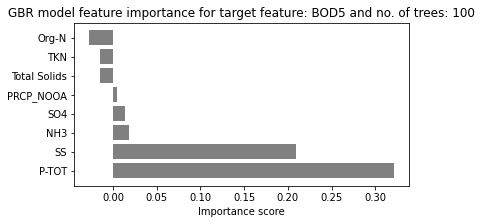

no of trees:  500
feature importance values {'Total Solids': 0.15305114674960568, 'SS': 0.255636591272665, 'NH3': 0.02803620496452056, 'Org-N': 0.07504111797188387, 'P-TOT': 0.4393903541853239, 'SO4': 0.016727685833096112, 'TKN': 0.028729128847662853, 'PRCP_NOOA': 0.003387770175242}
r2_score of the model 0.7075087548893912
Mean Squared Error of the model 1322.1761568002719


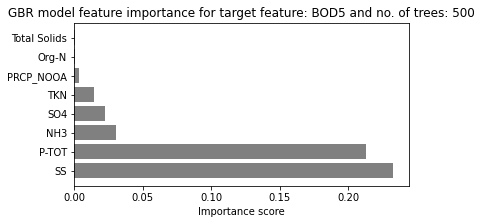

Building Gradient Boosting Regressor model for predictor:  NH3 
no of trees:  25
feature importance values {'Total Solids': 0.001047219147268939, 'SS': 0.0, 'BOD5': 0.0, 'Org-N': 0.12242903361274753, 'P-TOT': 0.0, 'SO4': 0.0, 'TKN': 0.8765237472399835, 'PRCP_NOOA': 0.0}
r2_score of the model 0.933961602579298
Mean Squared Error of the model 1.7821256308662878


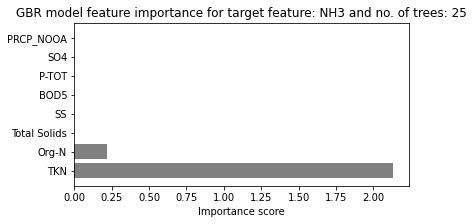

no of trees:  50
feature importance values {'Total Solids': 0.002115497826533793, 'SS': 7.075678051622594e-05, 'BOD5': 1.9042746296000148e-05, 'Org-N': 0.13708684233127838, 'P-TOT': 0.0015436114987685222, 'SO4': 2.8089572655736874e-06, 'TKN': 0.8591614398593416, 'PRCP_NOOA': 0.0}
r2_score of the model 0.9706158884013403
Mean Squared Error of the model 0.7929656149376937


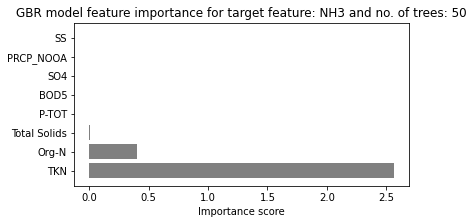

no of trees:  100
feature importance values {'Total Solids': 0.0023185525217822973, 'SS': 0.0004538643925083581, 'BOD5': 0.00033404413896272227, 'Org-N': 0.1435144569743428, 'P-TOT': 0.0020976486481068903, 'SO4': 1.81061343445407e-05, 'TKN': 0.8510629566704504, 'PRCP_NOOA': 0.000200370519501997}
r2_score of the model 0.9850527104807466
Mean Squared Error of the model 0.40337059657189606


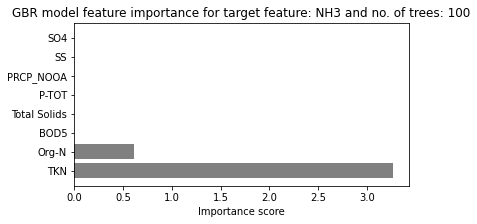

no of trees:  500
feature importance values {'Total Solids': 0.0025462096303562583, 'SS': 0.0007574772919463945, 'BOD5': 0.0005408277419088864, 'Org-N': 0.14503938824811954, 'P-TOT': 0.002371061303179098, 'SO4': 0.00018308394577847158, 'TKN': 0.8483016921884358, 'PRCP_NOOA': 0.00026025965027557594}
r2_score of the model 0.9887147792960906
Mean Squared Error of the model 0.3045452623311996


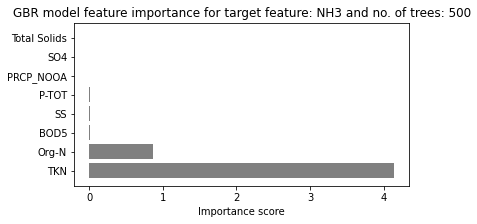

Building Gradient Boosting Regressor model for predictor:  Org-N 
no of trees:  25
feature importance values {'Total Solids': 0.0, 'SS': 0.14869289648725606, 'BOD5': 0.00306092969587758, 'NH3': 0.07186750127725358, 'P-TOT': 0.2337962291680541, 'SO4': 0.0, 'TKN': 0.5425824433715588, 'PRCP_NOOA': 0.0}
r2_score of the model 0.8549412600848879
Mean Squared Error of the model 3.1825021155293314


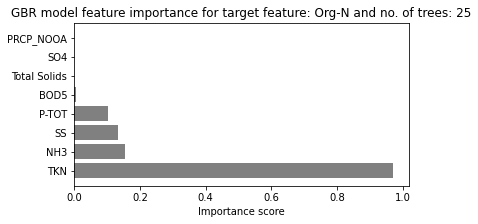

no of trees:  50
feature importance values {'Total Solids': 0.0007774499095981946, 'SS': 0.1426072729528422, 'BOD5': 0.0029539276097191878, 'NH3': 0.09394619712338516, 'P-TOT': 0.22089833724064703, 'SO4': 0.0, 'TKN': 0.5388168151638082, 'PRCP_NOOA': 0.0}
r2_score of the model 0.9089971319577541
Mean Squared Error of the model 1.996548572207142


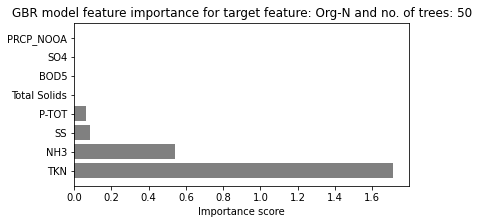

no of trees:  100
feature importance values {'Total Solids': 0.0007567934189813693, 'SS': 0.14320453302289332, 'BOD5': 0.0032706505646113216, 'NH3': 0.10214542347305161, 'P-TOT': 0.21664578129301754, 'SO4': 0.0, 'TKN': 0.5339655371504235, 'PRCP_NOOA': 1.1281077021388575e-05}
r2_score of the model 0.9232444654188204
Mean Squared Error of the model 1.6839705854754934


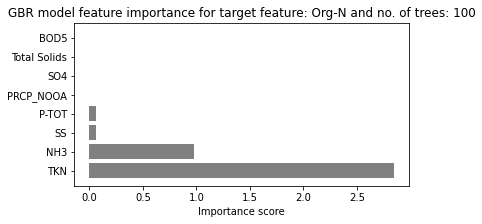

no of trees:  500
feature importance values {'Total Solids': 0.0011727464942092051, 'SS': 0.14331018699638565, 'BOD5': 0.0036257725888644596, 'NH3': 0.1072541985065955, 'P-TOT': 0.21325314029185366, 'SO4': 0.001630096624303714, 'TKN': 0.5296930717964514, 'PRCP_NOOA': 6.078670133629411e-05}
r2_score of the model 0.940541390919201
Mean Squared Error of the model 1.3044863708095737


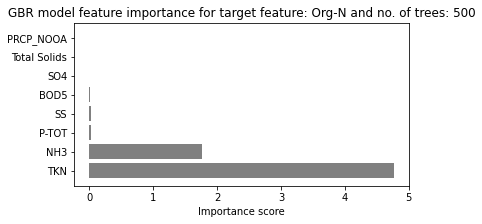

Building Gradient Boosting Regressor model for predictor:  P-TOT 
no of trees:  25
feature importance values {'Total Solids': 0.0031294137670675065, 'SS': 0.06218610012025709, 'BOD5': 0.08995574233898918, 'NH3': 0.007305509842060357, 'Org-N': 0.1637799298434481, 'SO4': 0.0, 'TKN': 0.6736433040881779, 'PRCP_NOOA': 0.0}
r2_score of the model 0.8602549608049588
Mean Squared Error of the model 0.3619723379282988


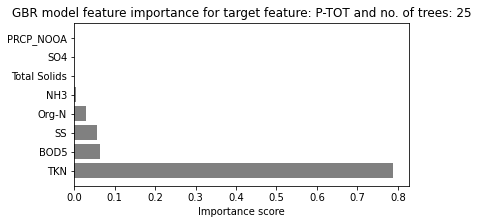

no of trees:  50
feature importance values {'Total Solids': 0.003773079800558959, 'SS': 0.06835265218331495, 'BOD5': 0.0916230077372322, 'NH3': 0.009995739530783209, 'Org-N': 0.16155680681011536, 'SO4': 0.00023437572129494024, 'TKN': 0.6643828184034101, 'PRCP_NOOA': 8.151981329034543e-05}
r2_score of the model 0.8740972930828318
Mean Squared Error of the model 0.3261174596022864


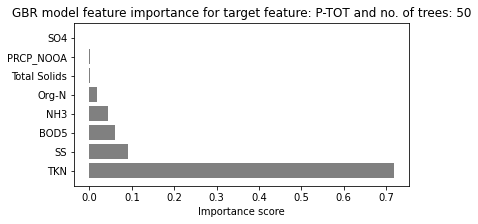

no of trees:  100
feature importance values {'Total Solids': 0.0043532670763047334, 'SS': 0.06876772900584627, 'BOD5': 0.0920942187980042, 'NH3': 0.010686927175793687, 'Org-N': 0.16188596173034203, 'SO4': 0.0017385885753651283, 'TKN': 0.6601320478588872, 'PRCP_NOOA': 0.00034125977945679556}
r2_score of the model 0.8767710833299189
Mean Squared Error of the model 0.31919171746186453


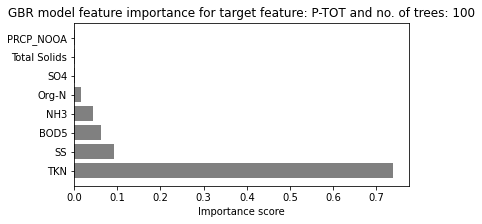

no of trees:  500
feature importance values {'Total Solids': 0.009811169342343263, 'SS': 0.06951438659752111, 'BOD5': 0.0928696358551296, 'NH3': 0.014788901694252211, 'Org-N': 0.16012395683205335, 'SO4': 0.0071547003369647035, 'TKN': 0.6447253165700502, 'PRCP_NOOA': 0.0010119327716855686}
r2_score of the model 0.8785992086797341
Mean Squared Error of the model 0.31445644520668986


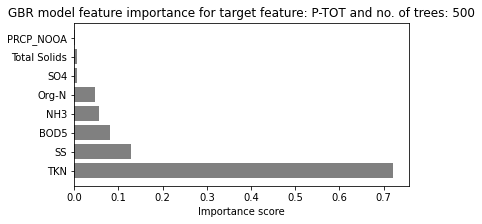

Building Gradient Boosting Regressor model for predictor:  SO4 
no of trees:  25
feature importance values {'Total Solids': 0.0665680732573227, 'SS': 0.1724949452661561, 'BOD5': 0.1751594856649548, 'NH3': 0.3093918202985296, 'Org-N': 0.06556231934174984, 'P-TOT': 0.09441011035186385, 'TKN': 0.07896650989665567, 'PRCP_NOOA': 0.03744673592276758}
r2_score of the model 0.10070661371677281
Mean Squared Error of the model 247.3487868023078


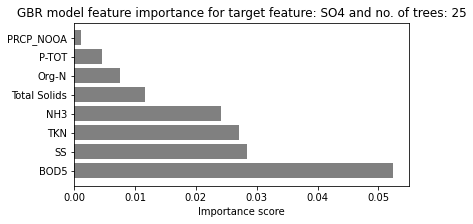

no of trees:  50
feature importance values {'Total Solids': 0.094072305094709, 'SS': 0.16415967707885093, 'BOD5': 0.16886964471567484, 'NH3': 0.26992886375349656, 'Org-N': 0.07132305796918238, 'P-TOT': 0.11227739519821367, 'TKN': 0.08039490350305115, 'PRCP_NOOA': 0.03897415268682147}
r2_score of the model 0.10519071241110778
Mean Squared Error of the model 246.11544472633682


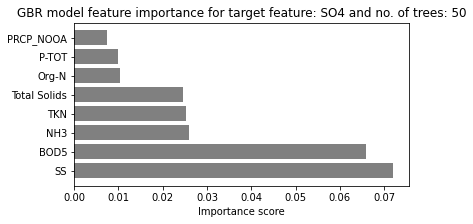

no of trees:  100
feature importance values {'Total Solids': 0.11145918046308032, 'SS': 0.16214272925797132, 'BOD5': 0.165936810225989, 'NH3': 0.24285534987922985, 'Org-N': 0.0773486203767413, 'P-TOT': 0.11723044616922607, 'TKN': 0.07917085290545603, 'PRCP_NOOA': 0.04385601072230609}
r2_score of the model 0.10306385748009572
Mean Squared Error of the model 246.70043177829834


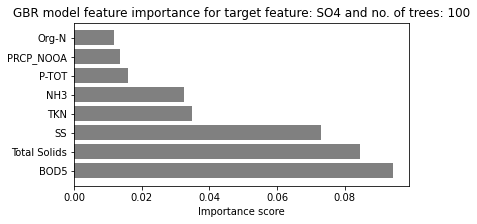

no of trees:  500
feature importance values {'Total Solids': 0.1297381103577663, 'SS': 0.1379646873343938, 'BOD5': 0.14830991732854926, 'NH3': 0.20071155380465316, 'Org-N': 0.09122512785652057, 'P-TOT': 0.13395646459696967, 'TKN': 0.11290967155774348, 'PRCP_NOOA': 0.045184467163403734}
r2_score of the model 0.06690419981439133
Mean Squared Error of the model 256.646070866966


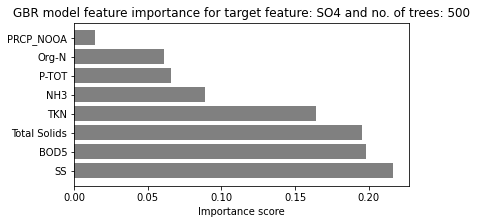

Building Gradient Boosting Regressor model for predictor:  TKN 
no of trees:  25
feature importance values {'Total Solids': 0.0, 'SS': 0.0, 'BOD5': 0.0, 'NH3': 0.2674744138977285, 'Org-N': 0.25525994502490024, 'P-TOT': 0.47726564107737135, 'SO4': 0.0, 'PRCP_NOOA': 0.0}
r2_score of the model 0.967890794055223
Mean Squared Error of the model 2.144360456326843


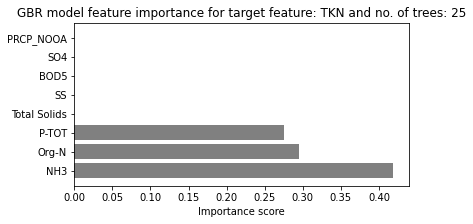

no of trees:  50
feature importance values {'Total Solids': 0.0, 'SS': 0.00029240372395227963, 'BOD5': 4.140240220027316e-05, 'NH3': 0.27071945432530403, 'Org-N': 0.261009003968109, 'P-TOT': 0.46793773558043444, 'SO4': 0.0, 'PRCP_NOOA': 0.0}
r2_score of the model 0.9850939632160766
Mean Squared Error of the model 0.9954751261981316


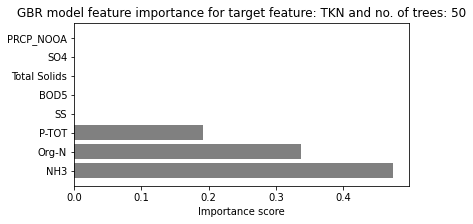

no of trees:  100
feature importance values {'Total Solids': 8.732993297528087e-06, 'SS': 0.0005293314108030881, 'BOD5': 0.00013187008560935635, 'NH3': 0.270864252877924, 'Org-N': 0.26156522383791664, 'P-TOT': 0.466889017178832, 'SO4': 1.7534607189709702e-06, 'PRCP_NOOA': 9.818154898303693e-06}
r2_score of the model 0.9901733803203506
Mean Squared Error of the model 0.6562546173406951


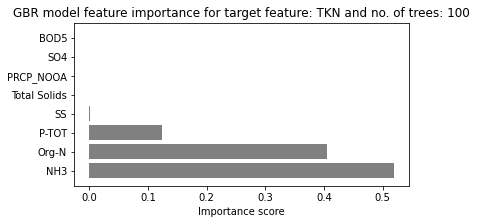

no of trees:  500
feature importance values {'Total Solids': 5.5353079868164454e-05, 'SS': 0.0006163890800175195, 'BOD5': 0.00019481305472203436, 'NH3': 0.27106488384806177, 'Org-N': 0.2619522593066434, 'P-TOT': 0.46605087957502456, 'SO4': 4.283698198301314e-05, 'PRCP_NOOA': 2.2585073679512634e-05}
r2_score of the model 0.9934597916986615
Mean Squared Error of the model 0.43677704399326783


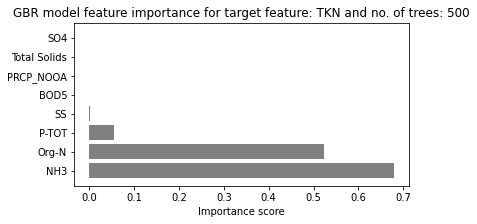

Building Gradient Boosting Regressor model for predictor:  PRCP_NOOA 
no of trees:  25
feature importance values {'Total Solids': 0.3038246123297068, 'SS': 0.37899544768922394, 'BOD5': 0.059519850781164625, 'NH3': 0.13155341765086256, 'Org-N': 0.030065341720328796, 'P-TOT': 0.014895086314510876, 'SO4': 0.052348490949883836, 'TKN': 0.028797752564318567}
r2_score of the model 0.03933146853489411
Mean Squared Error of the model 0.05971944941281222


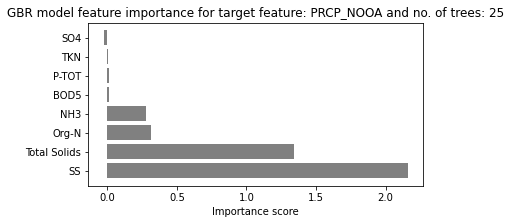

no of trees:  50
feature importance values {'Total Solids': 0.28290428685246005, 'SS': 0.3405284983905599, 'BOD5': 0.06530277672317851, 'NH3': 0.13303288239973332, 'Org-N': 0.04259554541676322, 'P-TOT': 0.025545018643869283, 'SO4': 0.061755298019431804, 'TKN': 0.048335693554003946}
r2_score of the model -0.028659755398370068
Mean Squared Error of the model 0.06394608776434153


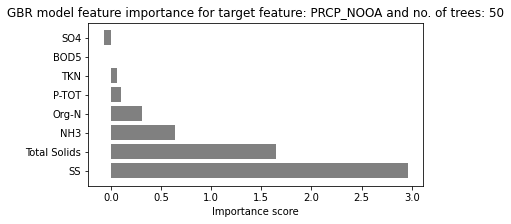

no of trees:  100
feature importance values {'Total Solids': 0.2631134987744798, 'SS': 0.3103975592947163, 'BOD5': 0.06923442478240266, 'NH3': 0.15092266529547518, 'Org-N': 0.05369691739128493, 'P-TOT': 0.037318266183013614, 'SO4': 0.06015645489818158, 'TKN': 0.05516021338044585}
r2_score of the model -0.06480044696967124
Mean Squared Error of the model 0.06619275467529444


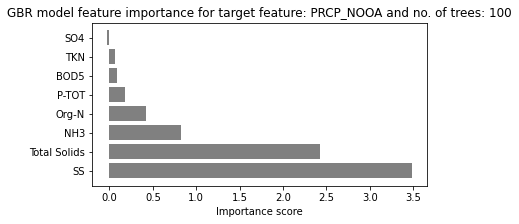

no of trees:  500
feature importance values {'Total Solids': 0.23338274619740226, 'SS': 0.2614802146526166, 'BOD5': 0.07213070170626144, 'NH3': 0.16075144519872275, 'Org-N': 0.06073314763818013, 'P-TOT': 0.06415892622666458, 'SO4': 0.05684837391806825, 'TKN': 0.09051444446208397}
r2_score of the model -0.18787561669100983
Mean Squared Error of the model 0.07384365728260413


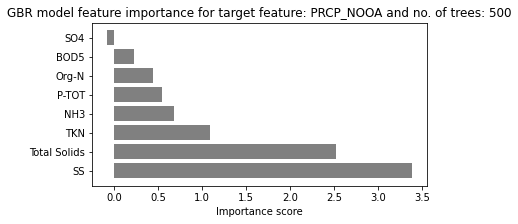

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
for j in ['Total Solids', 'SS', 'BOD5', 'NH3', 'Org-N', 'P-TOT', 'SO4', 'TKN', 'PRCP_NOOA']:
    print('\033[1m' + 'Building Gradient Boosting Regressor model for predictor: ', j, '\033[0m')
    # create target and features for model training
    label = water_new[j]
    train = water_new.drop(columns=[j])
    # test and train split with split ratio of 25:75
    X_train, X_test, y_train, y_test = train_test_split(train, label, test_size= 0.25, random_state=32)
    for i in [25, 50, 100, 500]:
        print('no of trees: ', i)
        gbr = GradientBoostingRegressor(n_estimators=i,random_state = 32)
        gbr.fit(X_train, y_train)
        print('feature importance values' , dict(zip(X_train.columns, gbr.feature_importances_)))
        print('r2_score of the model', r2_score(y_test,gbr.predict(X_test)))
        print('Mean Squared Error of the model', mean_squared_error(y_test, gbr.predict(X_test)))
        imp = rfpimp.importances(gbr, X_test, y_test)
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.barh(imp.index, imp['Importance'], height=0.8, facecolor='grey')
        ax.set_xlabel('Importance score')
        ax.set_title('GBR model feature importance for target feature: ' + str(j) + ' and no. of trees: ' + str(i))
        plt.show()

#Conclusion
After applying all the five models Random forest regression, Gradient boosting regression, Ridge, Linear, Support vector regressor. Random forest and gradient boosting did well in correctly predicting the target features.
